In [2]:
#Imports

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from collections import Counter

In [3]:
# INPUT
data_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_color")


In [4]:
total_images = 0

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    
    if class_path.is_dir():
        num_images = len(os.listdir(class_path))
        total_images += num_images

print("Total Images:", total_images)

Total Images: 54305


In [5]:
#Exploratory Data Analysis(EDA)
#Class Distribution

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name
    if class_path.is_dir():
        class_counts[class_name] = len(os.listdir(class_path))

# Print counts
for k, v in class_counts.items():
    print(f"{k}: {v}")

Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___healthy: 854
Cherry_(including_sour)___Powdery_mildew: 1052
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___healthy: 1162
Corn_(maize)___Northern_Leaf_Blight: 985
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___healthy: 423
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___healthy: 152
Potato___Late_blight: 1000
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___healthy: 456
Strawberry___Leaf_scorch: 1109
Tomato___Bacterial_spot: 2127
Tomato___Early_blight: 1000
Tomato___healthy: 1591
Tomato___Late_blight: 1909
Tomato___Leaf_Mold

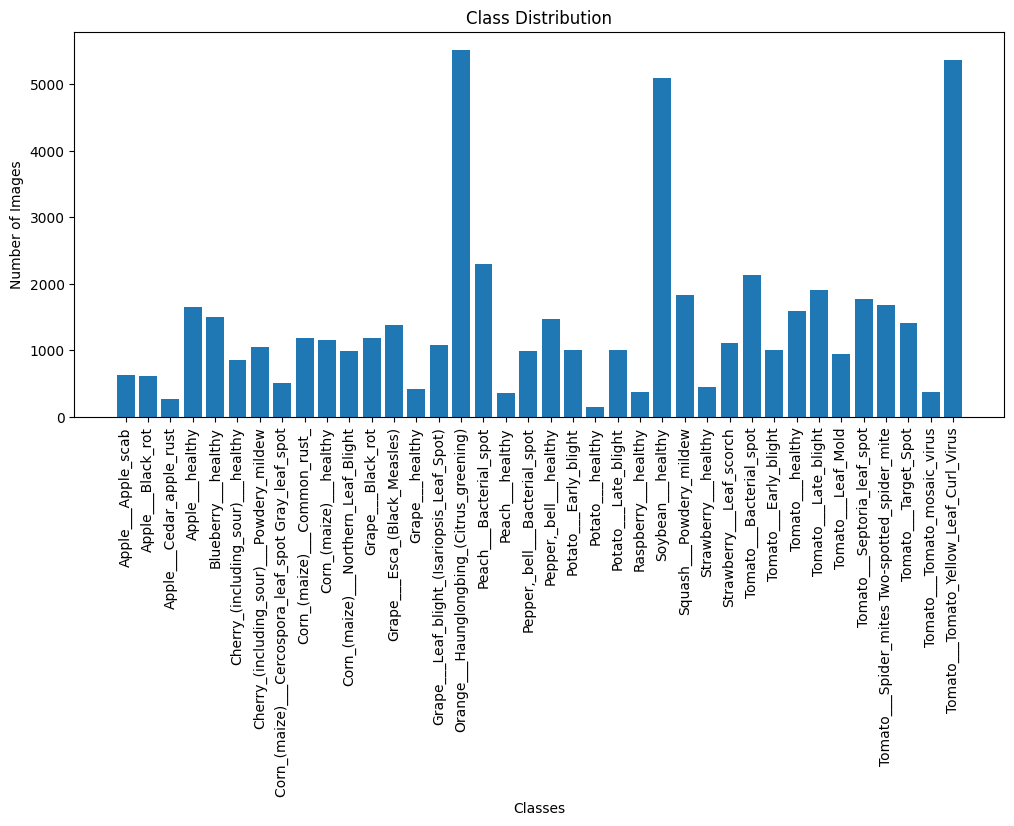

In [6]:
#Plot Class Distribution

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

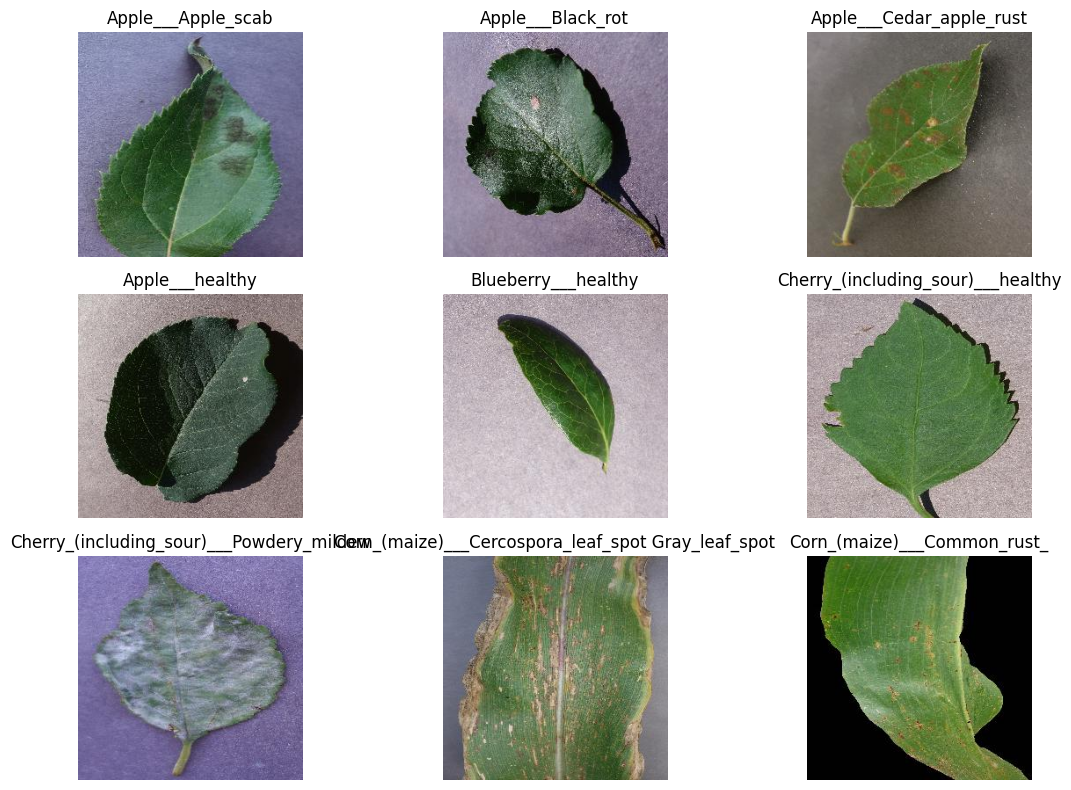

In [7]:
#Sample Image Visualization


plt.figure(figsize=(12,8))

classes = list(class_counts.keys())

for i, class_name in enumerate(classes[:9]):  # first 9 classes
    class_path = data_dir / class_name
    img_name = random.choice(os.listdir(class_path))
    img_path = class_path / img_name
    
    img = plt.imread(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
#Train/Val/Test Split
#Split Function

import shutil
# OUTPUT
output_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split")

train_dir = output_dir / "train"
val_dir   = output_dir / "val"
test_dir  = output_dir / "test"


for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

In [9]:
import os, shutil, random
from pathlib import Path

# ✅ INPUT DATASET
data_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_color")

# ✅ OUTPUT
output_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split")

train_dir = output_dir / "train"
test_dir  = output_dir / "test"
val_dir = output_dir / "val"

# ✅ clean old split (IMPORTANT)
if output_dir.exists():
    shutil.rmtree(output_dir)

train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)
for class_name in os.listdir(data_dir):
    class_path = data_dir / class_name

    if not class_path.is_dir():
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)

    # ✅ CORRECT INDENTATION
    train_split = int(0.7 * len(images))
    val_split   = int(0.85 * len(images))

    train_images = images[:train_split]
    val_images   = images[train_split:val_split]
    test_images  = images[val_split:]

    for split_name, split_images in zip(
        ['train', 'val', 'test'],
        [train_images, val_images, test_images]
    ):
        split_dir = output_dir / split_name

        (split_dir / class_name).mkdir(parents=True, exist_ok=True)

        for img in split_images:
            src = class_path / img
            dst = split_dir / class_name / img

            shutil.copy2(src, dst)
print("✅ Data Split Done")

✅ Data Split Done


In [10]:
data_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_color")

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [11]:
#Normalize + Prefetch

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))


AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)


In [12]:
def print_dataset_details(folder, name):
    print(f"\n📂 {name} Folder:")
    
    total = 0
    
    for class_name in os.listdir(folder):
        class_path = folder / class_name
        
        if class_path.is_dir():
            num_images = len(os.listdir(class_path))
            total += num_images
            print(f"{class_name}: {num_images}")
    
    print(f"👉 Total {name} Images: {total}")
print_dataset_details(train_dir, "Train")
print_dataset_details(val_dir, "Validation")
print_dataset_details(test_dir, "Test")


📂 Train Folder:
Apple___Apple_scab: 441
Apple___Black_rot: 434
Apple___Cedar_apple_rust: 192
Apple___healthy: 1151
Blueberry___healthy: 1051
Cherry_(including_sour)___healthy: 597
Cherry_(including_sour)___Powdery_mildew: 736
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 359
Corn_(maize)___Common_rust_: 834
Corn_(maize)___healthy: 813
Corn_(maize)___Northern_Leaf_Blight: 689
Grape___Black_rot: 826
Grape___Esca_(Black_Measles): 968
Grape___healthy: 296
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 753
Orange___Haunglongbing_(Citrus_greening): 3854
Peach___Bacterial_spot: 1607
Peach___healthy: 251
Pepper,_bell___Bacterial_spot: 697
Pepper,_bell___healthy: 1034
Potato___Early_blight: 700
Potato___healthy: 106
Potato___Late_blight: 700
Raspberry___healthy: 259
Soybean___healthy: 3563
Squash___Powdery_mildew: 1284
Strawberry___healthy: 319
Strawberry___Leaf_scorch: 776
Tomato___Bacterial_spot: 1488
Tomato___Early_blight: 700
Tomato___healthy: 1113
Tomato___Late_blight: 1336
Tomato___Le

### WEEK 2: Custom CNN Architecture and Baseline Training


In [13]:
# =====================================================
# IMPORTS
# =====================================================
import os
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [14]:
# =====================================================
# PATHS
# =====================================================
base_dir = Path(r"C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split")
train_dir = base_dir / "train"
val_dir = base_dir / "val"
test_dir = base_dir / "test"

MODEL_PATH = "best_cnn_model.keras"

# =====================================================
# CONFIG
# =====================================================
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 500
NUM_CLASSES = len(os.listdir(train_dir)) #Auto-detect number of class

print(f"Train : {train_dir}")
print(f" Val : {val_dir}")
print(f" Test : {test_dir}")
print(f" Number of Classes : {NUM_CLASSES}")

Train : C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split\train
 Val : C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split\val
 Test : C:\Users\user\Documents\Agriculture & Smart Farming\PlantVillage_split\test
 Number of Classes : 38


In [15]:
# =====================================================
# DATA GENERATOR
# =====================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)


NUM_CLASSES= len(train_generator.class_indices)
print(f" Classes loaded: {NUM_CLASSES} classes")
print(f" Train batches : {len(train_generator)}")
print(f" val batches : {len(val_generator)}")
print(f" Test batches : {len(test_generator)}")




Found 37997 images belonging to 38 classes.
Found 8146 images belonging to 38 classes.
Found 8162 images belonging to 38 classes.
 Classes loaded: 38 classes
 Train batches : 2375
 val batches : 510
 Test batches : 511


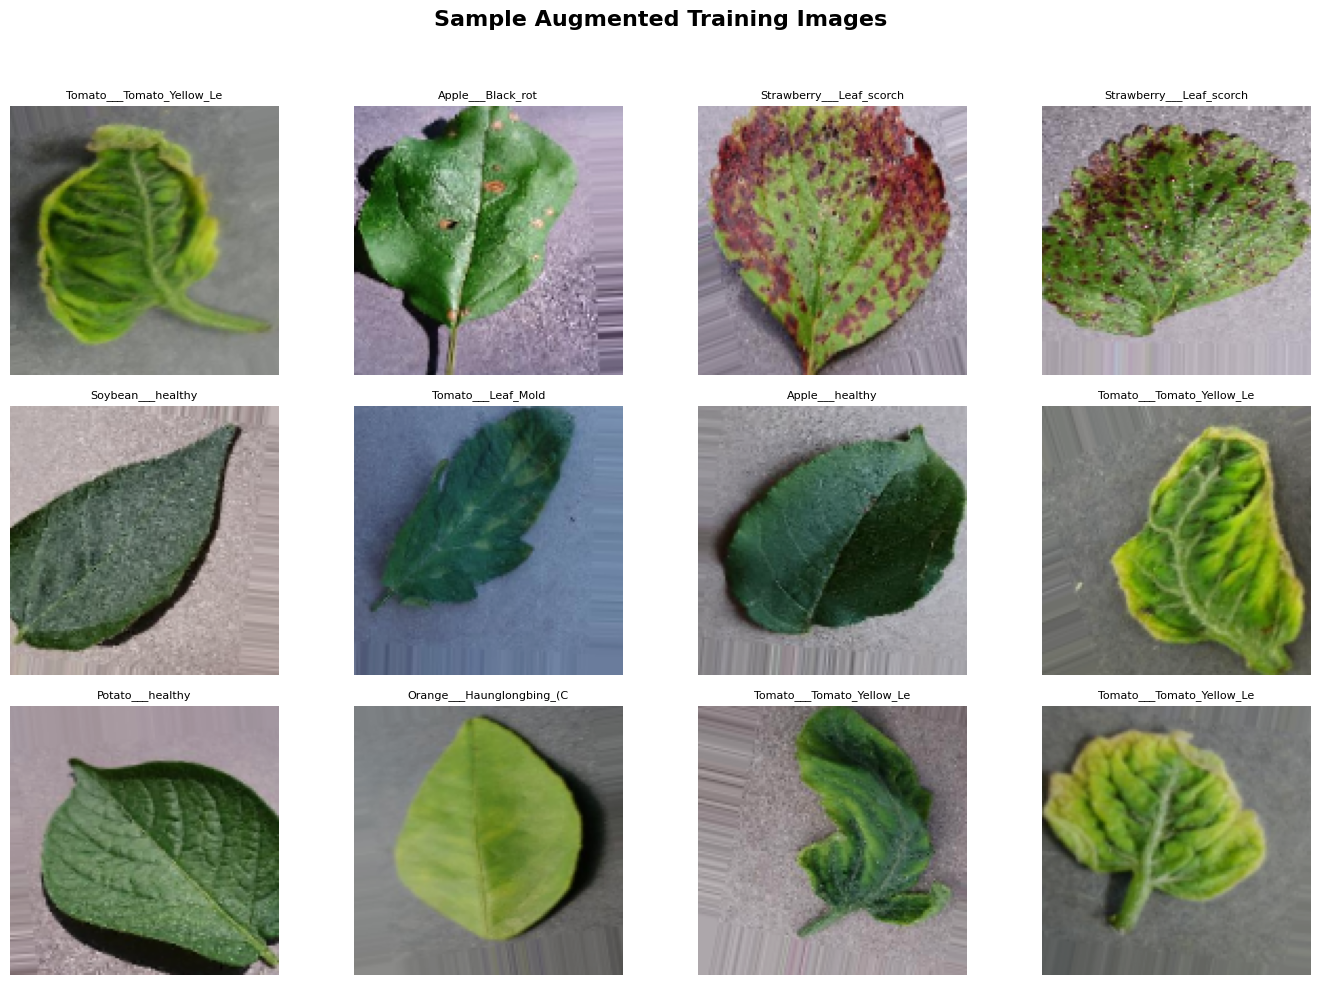

Augmented Sample images displayed


In [16]:
# Visualize Augmented Images (sanity check)
import matplotlib.pyplot as plt
import numpy as np

class_names = list(train_generator.class_indices.keys())

sample_batch, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 4, figsize =(14, 10))
fig.suptitle('Sample Augmented Training Images', fontsize= 16, fontweight= 'bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[i])
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(class_names[label_idx][:25],fontsize=8)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('augmented_samples.png',dpi =100, bbox_inches='tight')
plt.show()
print("Augmented Sample images displayed")

In [17]:
# =====================================================
# MODEL
# =====================================================
def build_custom_cnn(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model
    

num_classes = 38  
model = build_custom_cnn(num_classes)

model.summary()

C:\Users\user\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,038 (531.40 KB)

 Trainable params: 136,038 (531.40 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:

# =====================================================
# CALLBACKS
# =====================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print(f"✅ Calbacks configured")
print("   • EarlyStopping    (patience=5) ")
print("   • ModelCheckpoint  (save best model)")
print("   • ReduceLROnPlateau (patience=3)")


✅ Calbacks configured
   • EarlyStopping    (patience=5) 
   • ModelCheckpoint  (save best model)
   • ReduceLROnPlateau (patience=3)


In [19]:
print("Train:", len(train_generator.class_indices))
print("Val:", len(val_generator.class_indices))

print("\nTrain classes:")
print(train_generator.class_indices)

print("\nVal classes:")
print(val_generator.class_indices)

Train: 38
Val: 38

Train classes:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, '

In [20]:
# =====================================================
# 🔥 FIRST TRAINING
# =====================================================
print("\n🚀 FIRST TRAINING STARTED")

model = build_custom_cnn(NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("✅ First training done")



🚀 FIRST TRAINING STARTED
Epoch 1/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.2614 - loss: 2.7529
Epoch 1: val_accuracy improved from None to 0.51989, saving model to best_cnn_model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 958s 402ms/step - accuracy: 0.3680 - loss: 2.2590 - val_accuracy: 0.5199 - val_loss: 1.5843 - learning_rate: 0.0010
Epoch 2/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 970ms/step - accuracy: 0.5794 - loss: 1.4171
Epoch 2: val_accuracy improved from 0.51989 to 0.70771, saving model to best_cnn_model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 2339s 985ms/step - accuracy: 0.6109 - loss: 1.3042 - val_accuracy: 0.7077 - val_loss: 0.9722 - learning_rate: 0.0010
Epoch 3/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.6789 - loss: 1.0599
Epoch 3: val_accuracy improved from 0.70771 to 0.77302, saving model to best_cnn_model.keras
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 765s 322ms/step - accuracy: 0.6974 - loss: 0.9940 - val_accuracy: 0.7730 - val_loss: 0.7374 - learn

In [21]:
# =====================================================
# 🔥 LOAD BEST MODEL
# =====================================================
print("\n🔁 Loading BEST model for second training...")
model = tf.keras.models.load_model(MODEL_PATH)

# Lower LR for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


🔁 Loading BEST model for second training...


In [22]:
# =====================================================
# 🔥 SECOND TRAINING
# =====================================================
print("\n🚀 SECOND TRAINING STARTED")

history2 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("✅ Second training done")



🚀 SECOND TRAINING STARTED
Epoch 1/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9578 - loss: 0.1292
Epoch 1: val_accuracy did not improve from 0.95360
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 743s 312ms/step - accuracy: 0.9578 - loss: 0.1292 - val_accuracy: 0.9423 - val_loss: 0.2191 - learning_rate: 1.0000e-04
Epoch 2/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9610 - loss: 0.1171
Epoch 2: val_accuracy did not improve from 0.95360
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 689s 290ms/step - accuracy: 0.9602 - loss: 0.1194 - val_accuracy: 0.9439 - val_loss: 0.2119 - learning_rate: 1.0000e-04
Epoch 3/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.9615 - loss: 0.1243
Epoch 3: val_accuracy did not improve from 0.95360
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 694s 292ms/step - accuracy: 0.9615 - loss: 0.1229 - val_accuracy: 0.9522 - val_loss: 0.1755 - learning_rate: 1.0000e-04
Epoch 4/500
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.9629 - loss: 0.1158
Epo

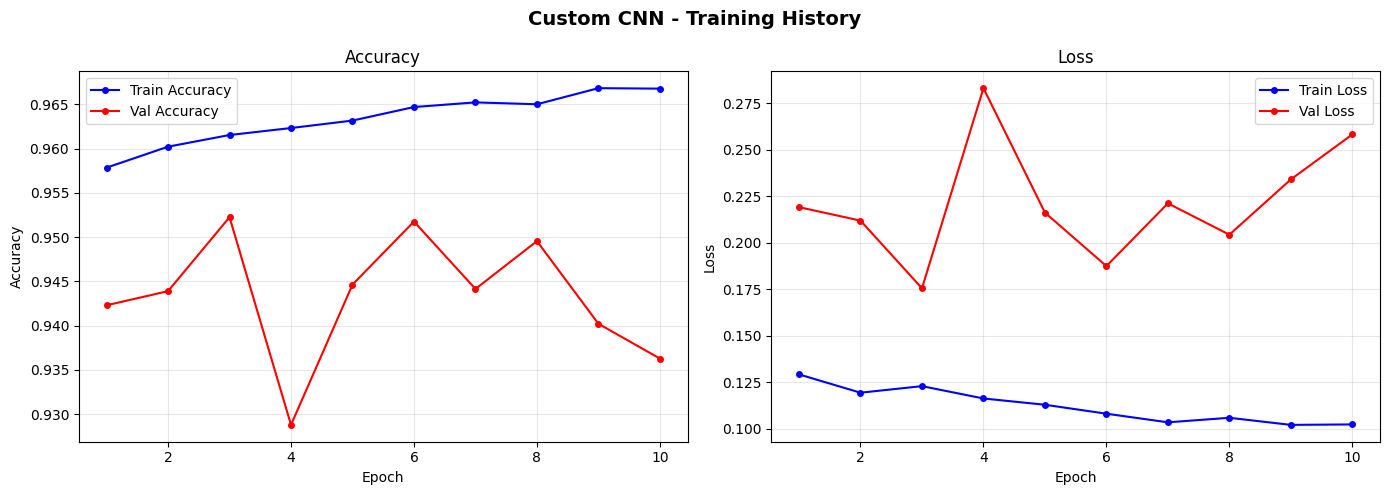


🔥 Best Validation Accuracy: 0.9522 (95.22%)

🧪 Testing final best model...
511/511 ━━━━━━━━━━━━━━━━━━━━ 105s 204ms/step - accuracy: 0.9514 - loss: 0.1665
🔥 Final Test Accuracy: 0.9514


In [23]:
import matplotlib.pyplot as plt
import tensorflow as tf

# =====================================================
# PLOT FUNCTION
# =====================================================
def plot_training_history(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} - Training History', fontsize=14, fontweight='bold')

    epochs_ran = range(1, len(history.history['accuracy']) + 1)

    # Accuracy Plot
    axes[0].plot(epochs_ran, history.history['accuracy'], 'b-o', label='Train Accuracy', markersize=4)
    axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Accuracy', markersize=4)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss Plot
    axes[1].plot(epochs_ran, history.history['loss'], 'b-o', label='Train Loss', markersize=4)
    axes[1].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss', markersize=4)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi=100, bbox_inches='tight')
    plt.show()


# =====================================================
# SELECT WHICH HISTORY TO USE 👇
# =====================================================
history = history2   # 👉 jodi 2nd training use korte chao
# history = history1  # 👉 jodi sudhu 1st training use korte chao


# =====================================================
# RUN PLOT + BEST VAL ACC
# =====================================================
plot_training_history(history, "Custom CNN")

if 'val_accuracy' in history.history:
    best_val_acc = max(history.history['val_accuracy'])
    print(f"\n🔥 Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
else:
    print("⚠️ No validation accuracy found!")


# =====================================================
# TEST BEST MODEL
# =====================================================
print("\n🧪 Testing final best model...")

model = tf.keras.models.load_model(MODEL_PATH)

test_loss, test_acc = model.evaluate(test_generator)

print(f"🔥 Final Test Accuracy: {test_acc:.4f}")